### Clustering (K-Means + BIRCH)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, Birch, DBSCAN
from kneed import KneeLocator
from sklearn.metrics import silhouette_score

In [3]:
# Load your data
data = pd.read_csv('merged_df.csv')

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72019 entries, 0 to 72018
Data columns (total 45 columns):
 #   Column                                               Non-Null Count  Dtype  
---  ------                                               --------------  -----  
 0   Unnamed: 0                                           72019 non-null  int64  
 1   Location                                             72019 non-null  object 
 2   URL                                                  72019 non-null  object 
 3   SKU                                                  72019 non-null  object 
 4   Title                                                72014 non-null  object 
 5   Price                                                72019 non-null  float64
 6   Category                                             72019 non-null  object 
 7   Num_Bedrooms                                         72019 non-null  float64
 8   Num_Bathrooms                                        72019 non-nul

In [7]:
house_df = data[data['Category'] == 'house']
condo_df = data[data['Category'] == 'condo']
apt_df = data[data['Category'] == 'apartment']
com_df = data[data['Category'] == 'commercial']
land_df = data[data['Category'] == 'land']

In [9]:
X_house = house_df[['Num_Bedrooms', 'Num_Bathrooms', 'Floor_Area', 'Land_Area', 'LRTHubDist', 'BusCount', 'MallCount', 
                    'SchoolCount', 'HospitalCount', 'ATMCount', 'financial_deepening', 'employment_generation', 'local_economy_growth', 
                    'local_economy_size', 'presence_of_business_and_professional_organizations', 'safety_compliant_business']]
X_condo = condo_df[['Num_Bedrooms', 'Num_Bathrooms', 'Floor_Area', 'Land_Area', 'LRTHubDist', 'BusCount', 'MallCount', 
                    'SchoolCount', 'HospitalCount', 'ATMCount', 'financial_deepening', 'employment_generation', 'local_economy_growth', 
                    'local_economy_size', 'presence_of_business_and_professional_organizations', 'safety_compliant_business']]
X_apt = apt_df[['Num_Bedrooms', 'Num_Bathrooms', 'Floor_Area', 'Land_Area', 'LRTHubDist', 'BusCount', 'MallCount', 
                    'SchoolCount', 'HospitalCount', 'ATMCount', 'financial_deepening', 'employment_generation', 'local_economy_growth', 
                    'local_economy_size', 'presence_of_business_and_professional_organizations', 'safety_compliant_business']]
X_com = com_df[['Num_Bedrooms', 'Num_Bathrooms', 'Floor_Area', 'Land_Area', 'LRTHubDist', 'BusCount', 'MallCount', 
                    'SchoolCount', 'HospitalCount', 'ATMCount', 'financial_deepening','employment_generation', 'local_economy_growth', 
                    'local_economy_size', 'presence_of_business_and_professional_organizations', 'safety_compliant_business']]
X_land = land_df[['Num_Bedrooms', 'Num_Bathrooms', 'Floor_Area', 'Land_Area', 'LRTHubDist', 'BusCount', 'MallCount', 
                    'SchoolCount', 'HospitalCount', 'ATMCount', 'financial_deepening','employment_generation', 'local_economy_growth', 
                    'local_economy_size', 'presence_of_business_and_professional_organizations', 'safety_compliant_business']]

In [11]:
y_house = house_df[['Price']]
y_condo = condo_df[['Price']]
y_apt = apt_df[['Price']]
y_com = com_df[['Price']]
y_land = land_df[['Price']]

In [13]:
longlat_house = house_df[['Latitude', 'Longitude']]
longlat_condo = condo_df[['Latitude', 'Longitude']]
longlat_apt = apt_df[['Latitude', 'Longitude']]
longlat_com = com_df[['Latitude', 'Longitude']]
longlat_land = land_df[['Latitude', 'Longitude']]

In [15]:
# Standardize the Price

y_house_scaled = pd.DataFrame(StandardScaler().fit_transform(y_house), columns=y_house.columns)
y_condo_scaled = pd.DataFrame(StandardScaler().fit_transform(y_condo), columns=y_condo.columns)
y_apt_scaled = pd.DataFrame(StandardScaler().fit_transform(y_apt), columns=y_apt.columns)
y_com_scaled = pd.DataFrame(StandardScaler().fit_transform(y_com), columns=y_com.columns)
y_land_scaled = pd.DataFrame(StandardScaler().fit_transform(y_land), columns=y_land.columns)

In [18]:
def find_optimal_clusters(X, max_clusters=10):
    """
    Finds the optimal number of clusters using the Elbow Method.
    
    Parameters:
        X (array-like): The dataset to cluster.
        max_clusters (int): Maximum number of clusters to test (default: 10).
    
    Returns:
        int: The optimal number of clusters.
    """
    inertias = []

    # Try different cluster sizes
    for k in range(1, max_clusters + 1):
        kmeans = KMeans(n_clusters=k, random_state=42)
        kmeans.fit(X)
        inertias.append(kmeans.inertia_)

    # Find the "elbow" using KneeLocator
    knee_locator = KneeLocator(range(1, max_clusters + 1), inertias, curve="convex", direction="decreasing")
    optimal_k = knee_locator.elbow

    # Handle the case where no elbow is detected
    if optimal_k is None:
        print("Warning: No clear elbow detected. Defaulting to max_clusters - 1.")
        optimal_k = max_clusters - 1  # Fallback strategy

    # Plot the Elbow Method graph
    plt.figure(figsize=(8, 5))
    plt.plot(range(1, max_clusters + 1), inertias, marker='o', linestyle='-')
    plt.axvline(x=optimal_k, color='r', linestyle='--', label=f"Optimal k = {optimal_k}")
    plt.xlabel("Number of Clusters (k)")
    plt.ylabel("Inertia (WCSS)")
    plt.title("Elbow Method for Optimal k")
    plt.xticks(range(1, max_clusters + 1))
    plt.grid(True)
    plt.legend()
    plt.show()

    print(f"Optimal number of clusters: {optimal_k}")
    return optimal_k

### House

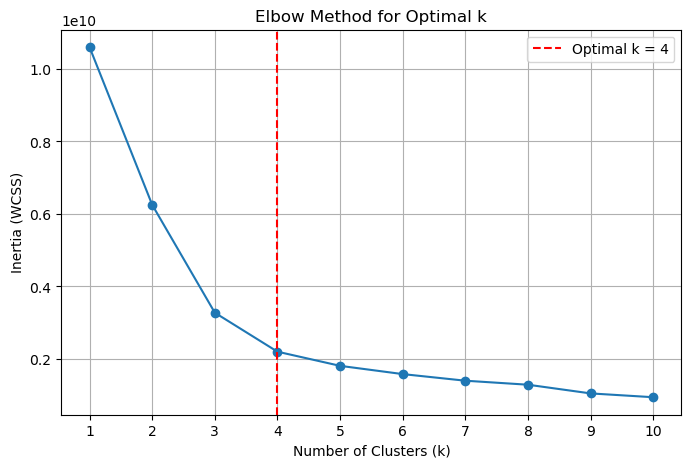

Optimal number of clusters: 4


4

In [21]:
find_optimal_clusters(X_house, max_clusters=10)

In [23]:
# Standardize the data
optimal_clusters = 4  # Change this to your optimal number of clusters

# K-Means Pipeline
kmeans_pipeline = make_pipeline(StandardScaler(), KMeans(n_clusters=optimal_clusters, random_state=42))

# BIRCH Pipeline
birch_pipeline = make_pipeline(StandardScaler(), Birch(n_clusters=optimal_clusters))

# DBSCAN Pipeline (corrected)
dbscan_pipeline = make_pipeline(StandardScaler(), DBSCAN(eps=0.5, min_samples=5))

In [25]:
kmeans_labels = kmeans_pipeline.fit_predict(X_house)
birch_labels = birch_pipeline.fit_predict(X_house)
dbscan_labels = dbscan_pipeline.fit_predict(X_house)

In [27]:
# Create copies for each clustering method
x_kmeans = house_df.copy()
x_birch = house_df.copy()
x_dbscan = house_df.copy()

# Add cluster labels
x_kmeans["Cluster"] = kmeans_labels
x_birch["Cluster"] = birch_labels
x_dbscan["Cluster"] = dbscan_labels

# Save each dataset as a separate CSV file
x_kmeans.to_csv("house_kmeans.csv", index=False)
x_birch.to_csv("house_birch.csv", index=False)
x_dbscan.to_csv("house_dbscan.csv", index=False)

In [29]:
def get_silhouette_score(pipeline, X):
    """
    Computes the silhouette score for a clustering pipeline.

    Parameters:
        pipeline: Fitted clustering pipeline (e.g., KMeans, BIRCH, DBSCAN)
        X: Original dataset used for clustering
    
    Returns:
        Silhouette score (float) or a message if not applicable
    """
    cluster_model = pipeline.named_steps[list(pipeline.named_steps.keys())[-1]]  # Last step = clustering model
    
    # Get cluster labels
    labels = cluster_model.labels_ if hasattr(cluster_model, "labels_") else cluster_model.predict(X)
    
    # Check if the clustering model found enough clusters for a silhouette score
    if len(set(labels)) < 2:
        return "Silhouette score cannot be computed (only one cluster found)."
    
    return silhouette_score(X, labels)

# Example usage:
kmeans_silhouette = get_silhouette_score(kmeans_pipeline, X_house)
birch_silhouette = get_silhouette_score(birch_pipeline, X_house)
dbscan_silhouette = get_silhouette_score(dbscan_pipeline, X_house)

print("K-Means Silhouette Score:", kmeans_silhouette)
print("BIRCH Silhouette Score:", birch_silhouette)
print("DBSCAN Silhouette Score:", dbscan_silhouette)

K-Means Silhouette Score: -0.00277990539789044
BIRCH Silhouette Score: 0.682682484267694
DBSCAN Silhouette Score: -0.5884926634058382


In [33]:
def get_top_features(pipeline, X, top_n=3):
    """
    Extracts the top `top_n` most defining features for each cluster in a clustering pipeline.
    
    Parameters:
        pipeline: Fitted clustering pipeline (e.g., KMeans, BIRCH, DBSCAN)
        X: Original DataFrame used for clustering
        top_n: Number of top features to extract per cluster (default: 3)
    
    Returns:
        DataFrame containing the top features and their values for each cluster
    """
    feature_names = X.columns  
    cluster_model = pipeline.named_steps[list(pipeline.named_steps.keys())[-1]]  # Last step = clustering model

    # Handle DBSCAN separately
    if isinstance(cluster_model, DBSCAN):
        labels = cluster_model.labels_
        unique_labels = set(labels) - {-1}  # Exclude noise points (-1)
        
        if not unique_labels:
            return "DBSCAN found no meaningful clusters."

        # Convert X to DataFrame for easier calculations
        X_df = pd.DataFrame(X, columns=feature_names)
        X_df["Cluster"] = labels  # Assign cluster labels

        global_means = X_df.iloc[:, :-1].mean()  # Mean of each feature in the dataset
        
        top_features_dict = {}

        for cluster in unique_labels:
            cluster_data = X_df[X_df["Cluster"] == cluster].iloc[:, :-1]  # Features only
            
            # Compute mean of each feature in this cluster
            cluster_means = cluster_data.mean()
            
            # Compute absolute deviation from global mean
            feature_importance = abs(cluster_means - global_means)
            
            # Get the top N most deviating features
            top_features = feature_importance.nlargest(top_n).items()
            
            # Store results
            top_features_dict[f'Cluster {cluster}'] = list(top_features)

        # Convert to DataFrame for better readability
        top_features_df = pd.DataFrame.from_dict(top_features_dict, orient='index', 
                                                 columns=[f'Top Feature {i+1}' for i in range(top_n)])
    
        return top_features_df

    # Handle K-Means & BIRCH (same as before)
    elif hasattr(cluster_model, "cluster_centers_"):
        cluster_centers = cluster_model.cluster_centers_
    elif hasattr(cluster_model, "subcluster_centers_"):
        cluster_centers = cluster_model.subcluster_centers_
    else:
        return "This clustering model does not support feature extraction."

    # Identify top N features for each cluster
    top_features_indices = np.argsort(np.abs(cluster_centers), axis=1)[:, -top_n:]

    top_features_dict = {}
    for cluster_idx, feature_indices in enumerate(top_features_indices):
        feature_info = [(feature_names[i], cluster_centers[cluster_idx, i]) for i in feature_indices]
        top_features_dict[f'Cluster {cluster_idx}'] = feature_info

    # Convert to DataFrame
    top_features_df = pd.DataFrame.from_dict(top_features_dict, orient='index', 
                                             columns=[f'Top Feature {i+1}' for i in range(top_n)])
    
    return top_features_df

# Example usage:
kmeans_features = get_top_features(kmeans_pipeline, X_house)
birch_features = get_top_features(birch_pipeline, X_house)
dbscan_features = get_top_features(dbscan_pipeline, X_house)

print("K-Means Top Features:\n", kmeans_features)
print("\nBIRCH Top Features:\n", birch_features)
print("\nDBSCAN Top Features:\n", dbscan_features)  # Now correctly calculates top features!

K-Means Top Features:
                                                Top Feature 1  \
Cluster 0       (employment_generation, -0.8103301938946066)   
Cluster 1  (presence_of_business_and_professional_organiz...   
Cluster 2                 (SchoolCount, -1.2723593213972284)   
Cluster 3                    (MallCount, 2.0847874263207173)   

                                         Top Feature 2  \
Cluster 0   (financial_deepening, -0.8965380598036359)   
Cluster 1    (local_economy_growth, 0.870502348597493)   
Cluster 2  (local_economy_growth, -1.5639317542808093)   
Cluster 3              (Land_Area, 2.2407228508903385)   

                                              Top Feature 3  
Cluster 0  (safety_compliant_business, -0.9487583028744532)  
Cluster 1         (financial_deepening, 0.9000916534209487)  
Cluster 2                   (LRTHubDist, 2.735241289997678)  
Cluster 3          (local_economy_size, 3.1463907381249703)  

BIRCH Top Features:
                                  

### Condo

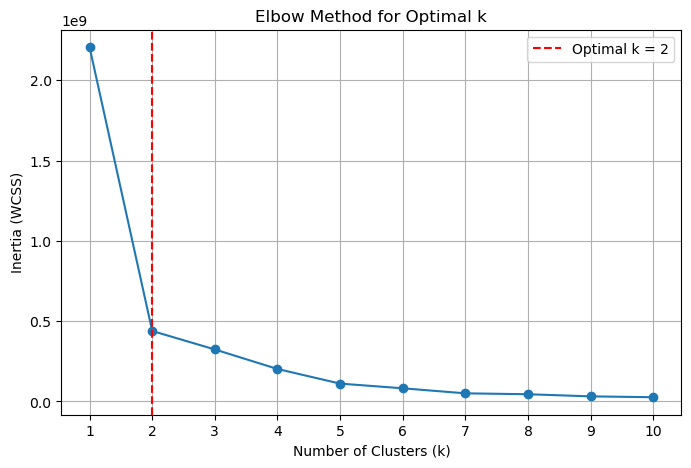

Optimal number of clusters: 2


2

In [36]:
find_optimal_clusters(X_condo, max_clusters=10)

In [38]:
optimal_clusters = 2
# K-Means Pipeline
kmeans_pipeline = make_pipeline(StandardScaler(), KMeans(n_clusters=optimal_clusters, random_state=42))

# BIRCH Pipeline
birch_pipeline = make_pipeline(StandardScaler(), Birch(n_clusters=optimal_clusters))

# DBSCAN Pipeline (corrected)
dbscan_pipeline = make_pipeline(StandardScaler(), DBSCAN(eps=0.5, min_samples=5))

kmeans_labels = kmeans_pipeline.fit_predict(X_condo)
birch_labels = birch_pipeline.fit_predict(X_condo)
dbscan_labels = dbscan_pipeline.fit_predict(X_condo)

In [40]:
# Create copies for each clustering method
x_kmeans = condo_df.copy()
x_birch = condo_df.copy()
x_dbscan = condo_df.copy()

# Add cluster labels
x_kmeans["Cluster"] = kmeans_labels
x_birch["Cluster"] = birch_labels
x_dbscan["Cluster"] = dbscan_labels

# Save each dataset as a separate CSV file
x_kmeans.to_csv("condo_kmeans.csv", index=False)
x_birch.to_csv("condo_birch.csv", index=False)
x_dbscan.to_csv("condo_dbscan.csv", index=False)

In [42]:
# Example usage:
kmeans_silhouette = get_silhouette_score(kmeans_pipeline, X_condo)
birch_silhouette = get_silhouette_score(birch_pipeline, X_condo)
dbscan_silhouette = get_silhouette_score(dbscan_pipeline, X_condo)

print("K-Means Silhouette Score:", kmeans_silhouette)
print("BIRCH Silhouette Score:", birch_silhouette)
print("DBSCAN Silhouette Score:", dbscan_silhouette)

K-Means Silhouette Score: -0.09183539761551783
BIRCH Silhouette Score: 0.9972482315192814
DBSCAN Silhouette Score: -0.36772190403927


In [44]:
# Example usage:
kmeans_features = get_top_features(kmeans_pipeline, X_condo)
birch_features = get_top_features(birch_pipeline, X_condo)
dbscan_features = get_top_features(dbscan_pipeline, X_condo)

print("K-Means Top Features:\n", kmeans_features)
print("\nBIRCH Top Features:\n", birch_features)
print("\nDBSCAN Top Features:\n", dbscan_features)  # Now correctly calculates top features!

K-Means Top Features:
                                                Top Feature 1  \
Cluster 0  (presence_of_business_and_professional_organiz...   
Cluster 1  (presence_of_business_and_professional_organiz...   

                                        Top Feature 2  \
Cluster 0  (financial_deepening, -1.7735722924144244)   
Cluster 1   (financial_deepening, 0.1685249816808021)   

                                         Top Feature 3  
Cluster 0   (local_economy_growth, 2.9579245681605975)  
Cluster 1  (local_economy_growth, -0.2810622300509051)  

BIRCH Top Features:
                                             Top Feature 1  \
Cluster 0                 (BusCount, -1.6297144087237498)   
Cluster 1     (local_economy_growth, -1.3009301087139138)   
Cluster 2              (SchoolCount, -1.3235046661468064)   
Cluster 3                (MallCount, -1.0474087921467006)   
Cluster 4                (MallCount, -1.0474087921467008)   
...                                                  

### Apt

C:\Users\Dianne Yumol\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\Dianne Yumol\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\Dianne Yumol\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\Dianne Yumol\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to 

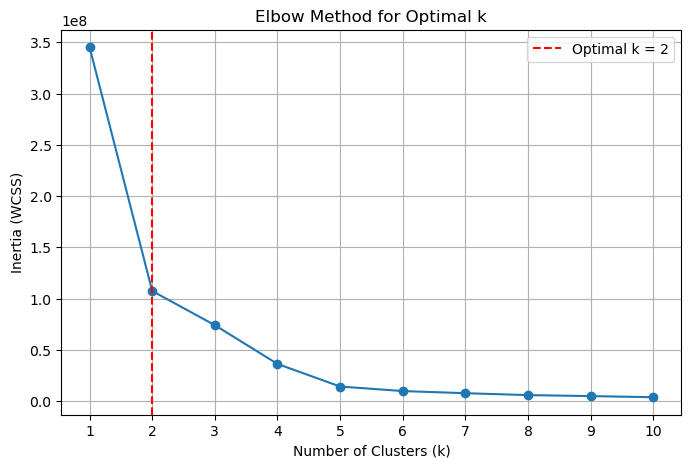

Optimal number of clusters: 2


2

In [47]:
find_optimal_clusters(X_apt, max_clusters=10)

In [49]:
optimal_clusters = 2

# K-Means Pipeline
kmeans_pipeline = make_pipeline(StandardScaler(), KMeans(n_clusters=optimal_clusters, random_state=42))

# BIRCH Pipeline
birch_pipeline = make_pipeline(StandardScaler(), Birch(n_clusters=optimal_clusters))

# DBSCAN Pipeline (corrected)
dbscan_pipeline = make_pipeline(StandardScaler(), DBSCAN(eps=0.5, min_samples=5))

kmeans_labels = kmeans_pipeline.fit_predict(X_apt)
birch_labels = birch_pipeline.fit_predict(X_apt)
dbscan_labels = dbscan_pipeline.fit_predict(X_apt)

C:\Users\Dianne Yumol\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


In [51]:
# Create copies for each clustering method
x_kmeans = apt_df.copy()
x_birch = apt_df.copy()
x_dbscan = apt_df.copy()

# Add cluster labels
x_kmeans["Cluster"] = kmeans_labels
x_birch["Cluster"] = birch_labels
x_dbscan["Cluster"] = dbscan_labels

# Save each dataset as a separate CSV file
x_kmeans.to_csv("apt_kmeans.csv", index=False)
x_birch.to_csv("apt_birch.csv", index=False)
x_dbscan.to_csv("apt_dbscan.csv", index=False)

In [53]:
# Example usage:
kmeans_silhouette = get_silhouette_score(kmeans_pipeline, X_apt)
birch_silhouette = get_silhouette_score(birch_pipeline, X_apt)
dbscan_silhouette = get_silhouette_score(dbscan_pipeline, X_apt)

print("K-Means Silhouette Score:", kmeans_silhouette)
print("BIRCH Silhouette Score:", birch_silhouette)
print("DBSCAN Silhouette Score:", dbscan_silhouette)

K-Means Silhouette Score: -0.0803554522876468
BIRCH Silhouette Score: 0.006647918792105456
DBSCAN Silhouette Score: -0.6335011660510845


In [55]:
# Example usage:
kmeans_features = get_top_features(kmeans_pipeline, X_apt)
birch_features = get_top_features(birch_pipeline, X_apt)
dbscan_features = get_top_features(dbscan_pipeline, X_apt)

print("K-Means Top Features:\n", kmeans_features)
print("\nBIRCH Top Features:\n", birch_features)
print("\nDBSCAN Top Features:\n", dbscan_features)  # Now correctly calculates top features!

K-Means Top Features:
                                                Top Feature 1  \
Cluster 0  (safety_compliant_business, -0.48480219478226544)   
Cluster 1    (safety_compliant_business, 0.8925797417953859)   

                                               Top Feature 2  \
Cluster 0  (presence_of_business_and_professional_organiz...   
Cluster 1  (presence_of_business_and_professional_organiz...   

                                        Top Feature 3  
Cluster 0  (financial_deepening, -0.6171795558539376)  
Cluster 1   (financial_deepening, 1.1363025467591168)  

BIRCH Top Features:
                                            Top Feature 1  \
Cluster 0                (LRTHubDist, 7.690125606107509)   
Cluster 1                (BusCount, -1.0830438242965765)   
Cluster 2       (financial_deepening, 1.404174468596531)   
Cluster 3    (local_economy_growth, -1.3846361796042002)   
Cluster 4    (local_economy_growth, -1.3846361796042002)   
...                                      

### Commercial Real Estate

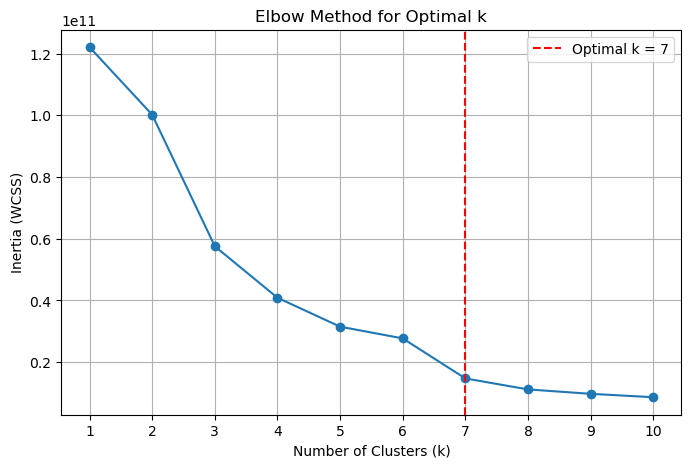

Optimal number of clusters: 7


7

In [58]:
find_optimal_clusters(X_com, max_clusters=10)

In [60]:
optimal_clusters = 7

# K-Means Pipeline
kmeans_pipeline = make_pipeline(StandardScaler(), KMeans(n_clusters=optimal_clusters, random_state=42))

# BIRCH Pipeline
birch_pipeline = make_pipeline(StandardScaler(), Birch(n_clusters=optimal_clusters))

# DBSCAN Pipeline (corrected)
dbscan_pipeline = make_pipeline(StandardScaler(), DBSCAN(eps=0.5, min_samples=5))

kmeans_labels = kmeans_pipeline.fit_predict(X_com)
birch_labels = birch_pipeline.fit_predict(X_com)
dbscan_labels = dbscan_pipeline.fit_predict(X_com)

In [62]:
# Create copies for each clustering method
x_kmeans = com_df.copy()
x_birch = com_df.copy()
x_dbscan = com_df.copy()

# Add cluster labels
x_kmeans["Cluster"] = kmeans_labels
x_birch["Cluster"] = birch_labels
x_dbscan["Cluster"] = dbscan_labels

# Save each dataset as a separate CSV file
x_kmeans.to_csv("com_kmeans.csv", index=False)
x_birch.to_csv("com_birch.csv", index=False)
x_dbscan.to_csv("com_dbscan.csv", index=False)

In [64]:
# Example usage:
kmeans_silhouette = get_silhouette_score(kmeans_pipeline, X_com)
birch_silhouette = get_silhouette_score(birch_pipeline, X_com)
dbscan_silhouette = get_silhouette_score(dbscan_pipeline, X_com)

print("K-Means Silhouette Score:", kmeans_silhouette)
print("BIRCH Silhouette Score:", birch_silhouette)
print("DBSCAN Silhouette Score:", dbscan_silhouette)

K-Means Silhouette Score: -0.08376561442818765
BIRCH Silhouette Score: -0.5267585449171649
DBSCAN Silhouette Score: -0.6690545378576208


In [66]:
# Example usage:
kmeans_features = get_top_features(kmeans_pipeline, X_com)
birch_features = get_top_features(birch_pipeline, X_com)
dbscan_features = get_top_features(dbscan_pipeline, X_com)

print("K-Means Top Features:\n", kmeans_features)
print("\nBIRCH Top Features:\n", birch_features)
print("\nDBSCAN Top Features:\n", dbscan_features)  # Now correctly calculates top features!

K-Means Top Features:
                                                Top Feature 1  \
Cluster 0                     (BusCount, 0.8793598096267995)   
Cluster 1         (financial_deepening, -0.9317912857723457)   
Cluster 2                     (BusCount, 0.5998105703752978)   
Cluster 3         (local_economy_growth, 0.8280997796966987)   
Cluster 4                   (Floor_Area, 2.7245121594881567)   
Cluster 5  (presence_of_business_and_professional_organiz...   
Cluster 6                 (SchoolCount, -1.2264614386476156)   

                                              Top Feature 2  \
Cluster 0                (HospitalCount, 1.423064558943937)   
Cluster 1  (safety_compliant_business, -1.0610124744446152)   
Cluster 2                    (ATMCount, 1.8796276605043556)   
Cluster 3         (financial_deepening, 1.4186938350572478)   
Cluster 4                  (LRTHubDist, 3.1337444429648027)   
Cluster 5        (employment_generation, 1.190080314463259)   
Cluster 6       (local_

### Land

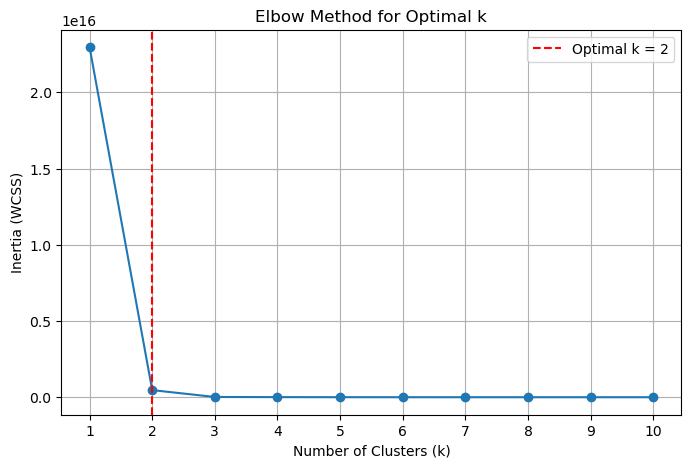

Optimal number of clusters: 2


2

In [69]:
find_optimal_clusters(X_land, max_clusters=10)

In [71]:
optimal_clusters = 2

# K-Means Pipeline
kmeans_pipeline = make_pipeline(StandardScaler(), KMeans(n_clusters=optimal_clusters, random_state=42))

# BIRCH Pipeline
birch_pipeline = make_pipeline(StandardScaler(), Birch(n_clusters=optimal_clusters))

# DBSCAN Pipeline (corrected)
dbscan_pipeline = make_pipeline(StandardScaler(), DBSCAN(eps=0.5, min_samples=5))

kmeans_labels = kmeans_pipeline.fit_predict(X_land)
birch_labels = birch_pipeline.fit_predict(X_land)
dbscan_labels = dbscan_pipeline.fit_predict(X_land)

In [72]:
# Create copies for each clustering method
x_kmeans = land_df.copy()
x_birch = land_df.copy()
x_dbscan = land_df.copy()

# Add cluster labels
x_kmeans["Cluster"] = kmeans_labels
x_birch["Cluster"] = birch_labels
x_dbscan["Cluster"] = dbscan_labels

# Save each dataset as a separate CSV file
x_kmeans.to_csv("land_kmeans.csv", index=False)
x_birch.to_csv("land_birch.csv", index=False)
x_dbscan.to_csv("land_dbscan.csv", index=False)

In [75]:
# Example usage:
kmeans_silhouette = get_silhouette_score(kmeans_pipeline, X_land)
birch_silhouette = get_silhouette_score(birch_pipeline, X_land)
dbscan_silhouette = get_silhouette_score(dbscan_pipeline, X_land)

print("K-Means Silhouette Score:", kmeans_silhouette)
print("BIRCH Silhouette Score:", birch_silhouette)
print("DBSCAN Silhouette Score:", dbscan_silhouette)

K-Means Silhouette Score: -0.22177887426240708
BIRCH Silhouette Score: -0.45491127111925206
DBSCAN Silhouette Score: -0.8324172775735093


In [77]:
# Example usage:
kmeans_features = get_top_features(kmeans_pipeline, X_land)
birch_features = get_top_features(birch_pipeline, X_land)
dbscan_features = get_top_features(dbscan_pipeline, X_land)

print("K-Means Top Features:\n", kmeans_features)
print("\nBIRCH Top Features:\n", birch_features)
print("\nDBSCAN Top Features:\n", dbscan_features)  # Now correctly calculates top features!

K-Means Top Features:
                                           Top Feature 1  \
Cluster 0  (employment_generation, -0.5162112670985692)   
Cluster 1   (employment_generation, 0.8615638753687306)   

                                         Top Feature 2  \
Cluster 0  (local_economy_growth, -0.5480191204758345)   
Cluster 1   (local_economy_growth, 0.9146516306533372)   

                                               Top Feature 3  
Cluster 0  (presence_of_business_and_professional_organiz...  
Cluster 1  (presence_of_business_and_professional_organiz...  

BIRCH Top Features:
                                                Top Feature 1  \
Cluster 0                    (BusCount, -0.7779554558049965)   
Cluster 1          (local_economy_size, -0.8514820050157057)   
Cluster 2    (safety_compliant_business, 1.3448904117322718)   
Cluster 3        (employment_generation, -1.047728326273111)   
Cluster 4       (employment_generation, -1.0736347864239362)   
...                          